In [1]:
#import 
from matplotlib import (pyplot as plt, patches, colors as mplCol)
import numpy as np
import pandas as pd
from astropy.coordinates import (SkyCoord, Distance, Galactic)
from astropy import (table, units as u)
from astropy.io import ascii
from scipy.stats import linregress
from astroquery.gaia import Gaia


In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [2]:
fun_3col = {'metallicity_standard': ['darkmagenta', 'darkcyan','green'],
           'contrast_plt': ['#7321bd', '#b62746', '#c59800']}

In [3]:
file = r'../files/photometric_datav4.csv'
full_data = pd.read_csv(file)
print(full_data.columns.to_list())
print(len(full_data))

['star', '2MASS ID', 'Gaia DR3 ID', 'AllWISE ID', 'GALEX ID', 'ra', 'dec', 'distance', 'vsini', 'VSX Period', 'Av', 'fe_h', 'm_G', 'Gaia G flux_over_error', 'm_BP', 'Gaia BP flux_over_error', 'm_RP', 'Gaia RP flux_over_error', '2MASS J', '2MASS J error', '2MASS H', '2MASS H error', '2MASS K', '2MASS K error', 'WISE W1', 'WISE W1 error', 'WISE W2', 'WISE W2 error', 'WISE W3', 'WISE W3 error', 'WISE W4', 'WISE W4 error', 'GALEX FUV', 'GALEX FUV Error', 'GALEX NUV', 'GALEX NUV Error', 'Li Profile', 'H-alpha Profile', 'Ca II H Profile', 'Ca II K Profile', '2MASS_qph', 'ALLWISE_ccf', 'ALLWISE_qph', 'leiner_class', 'updated_class']
1895


In [4]:
#get gaia ids
gaia_ids = str(list(full_data['Gaia DR3 ID'])).strip('[]')
#remove gaia data table
full_data_concat = full_data[['star',  '2MASS ID','Gaia DR3 ID', 'AllWISE ID', 'vsini', 'VSX Period', 'Av', 
                      '2MASS J', '2MASS J error', '2MASS H', '2MASS H error', '2MASS K', '2MASS K error', 
                     'WISE W1', 'WISE W1 error', 'WISE W2', 'WISE W2 error', 'WISE W3', 'WISE W3 error', 
                     'WISE W4', 'WISE W4 error', 'Li Profile', 'H-alpha Profile', 
                     'Ca II H Profile', 'Ca II K Profile', '2MASS_qph','ALLWISE_ccf', 'ALLWISE_qph', 'updated_class']]
full_data_concat = full_data_concat.rename(columns={'Gaia DR3 ID': 'source_id'})

#convert to astropy table
ffull_data_concat = table.Table.from_pandas(full_data_concat)

In [5]:
query_text = f'''SELECT TOP 3000 subquery.source_id, ra, dec, bp_rp, phot_g_mean_mag, 
mh_gspphot, parallax, pmra, pmdec, ruwe, galex.*
FROM (
  SELECT gaia.*, EPOCH_PROP_POS(ra, dec, parallax, pmra, pmdec, radial_velocity, ref_epoch, 2000) AS propagated_position_vector
  FROM gaiadr3.gaia_source AS gaia
  WHERE gaia.source_id IN ({gaia_ids})
  OFFSET 0) AS subquery
JOIN external.galex_ais AS galex
ON DISTANCE(COORD1(subquery.propagated_position_vector), 
COORD2(subquery.propagated_position_vector), galex.raj2000, galex.dej2000) < 3./3600.

'''



#f'''SELECT TOP 10000 *
#FROM gaiadr3.gaia_source 
#WHERE gaiadr3.gaia_source.source_id IN ({gaia_ids})'''

job = Gaia.launch_job(query_text) 
gaia_data = job.get_results()

In [6]:
print(job)

<Table length=1025>
      name       dtype    unit                                                    description                                                   n_bad
--------------- ------- -------- -------------------------------------------------------------------------------------------------------------- -----
      source_id   int64                                                      Unique source identifier (unique within a particular Data Release)     0
             ra float64      deg                                                                                                Right ascension     0
            dec float64      deg                                                                                                    Declination     0
          bp_rp float32      mag                                                                                                 BP - RP colour     0
phot_g_mean_mag float32      mag                                                

In [7]:
gaia_data = table.join(gaia_data, ffull_data_concat, keys = 'source_id')

In [8]:
gaia_data

source_id,ra,dec,bp_rp,phot_g_mean_mag,mh_gspphot,parallax,pmra,pmdec,ruwe,raj2000,dej2000,name,objid,phid,cat,rafdeg,defdeg,fuvexp,nuvexp,glon,glat,tile,img,sv,r_fov,obs,b,e_b_v,sp_,chkf,fuvmag,e_fuvmag,nuvmag,e_nuvmag,fuv_a,e_fuv_a,nuv_a,e_nuv_a,fuv_4,e_fuv_4,nuv_4,e_nuv_4,fuv_6,e_fuv_6,nuv_6,e_nuv_6,fafl,nafl,fexf,nexf,fflux,e_fflux,nflux,e_nflux,fxpos,fypos,nxpos,nypos,fima,nima,fr,nr,ns_g,fs_g,nell,fell,npa,e_npa,fpa,e_fpa,fnr,f3r,nar,narms,nbrms,far,farms,fbrms,nuvw,fuvw,prob,sep,nerr,ferr,ierr,nperr,fperr,cv,g,n,primid,groupid,gd,nd,primidd,groupidd,grouptot,oname,size,star,2MASS ID,AllWISE ID,vsini,VSX Period,Av,2MASS J,2MASS J error,2MASS H,2MASS H error,2MASS K,2MASS K error,WISE W1,WISE W1 error,WISE W2,WISE W2 error,WISE W3,WISE W3 error,WISE W4,WISE W4 error,Li Profile,H-alpha Profile,Ca II H Profile,Ca II K Profile,2MASS_qph,ALLWISE_ccf,ALLWISE_qph,updated_class
,deg,deg,mag,mag,dex,mas,mas / yr,mas / yr,,deg,deg,NULL,NULL,NULL,NULL,deg,deg,s,s,deg,deg,NULL,NULL,NULL,deg,NULL,NULL,mag,NULL,NULL,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,NULL,NULL,NULL,NULL,uJy,uJy,uJy,uJy,pix,pix,pix,pix,pix,pix,deg,deg,NULL,NULL,NULL,NULL,deg,deg,deg,deg,pix,pix,NULL,deg,deg,NULL,deg,deg,s,s,NULL,arcsec,arcsec,arcsec,arcsec,arcsec,arcsec,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,pix,,,,,,,,,,,,,,,,,,,,,,,,,,,,
int64,float64,float64,float32,float32,float32,float64,float64,float64,float32,float64,float64,str22,int64,int64,str3,float64,float64,float32,float32,float64,float64,int32,int16,int16,float64,int16,int16,float32,int16,int16,float32,float32,float32,float32,float32,float32,float64,float32,float32,float64,float32,float64,float32,float64,float32,float64,int16,int16,int16,int16,float64,float64,float64,float64,float32,float32,float32,float32,float64,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float32,float32,float64,float32,float32,float32,float32,float32,float32,object,int16,int16,int64,str239,int16,int16,int64,str239,str239,str31,float64,str28,str22,str25,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str3,str16,str18,str18,str3,str4,str4,str3
18910470421959808,40.65095558618673,7.290585245493459,1.7245846,8.409346,--,1.9747769984053039,13.376125652744392,-6.101651756946776,2.3110702,40.650845,7.290654,GALEX J024236.2+071726,6377248951056205179,6377248951053058048,AIS,41.063995,7.307181,196.05,196.05,164.9639,-46.3108,50180,257,8,0.410136,1,3,0.1013,0,1,19.6068,0.1267,16.5699,0.0177,0.7868,0.1267,-3.5101,0.0177,0.8482,0.1286,-3.4195,0.0185,0.7873,0.1356,-3.5054,0.0177,0,0,0,0,52.1522,6.08319,855.164,13.9043,2911.17,1896.4,2910.65,1896.39,4.696,3.226,0.002,0.001,0.9871,0.9856,0.1172,0.0665,-77.49,-89.98,-70.45,-70.53,5.93521976,2.72169995,3.5,0.001151,0.001016,3.5,0.00073,0.000682,153.8,136.0,0.644,0.5,0.47,0.69,0.53,0.04,0.08,C,0,1,6377248951056204800,6377248951056205179,0,1,6377248951056204800,6377248951056205179,6377248951056205179,N,0.0,HR Cet,2MASS 02423621+0717260,WISEA J024236.23+071726.0,--,52.84,0.28,6.244,0.021,5.565,0.047,5.245,0.021,5.004,0.234,4.642,0.135,2.719,0.011,1.669,0.017,--,--,--,--,AAA,0000,BBAA,RS
34148700855166720,43.83780066505116,15.656337721802666,1.4843063,10.65428,--,1.2561350761478272,5.895475784371175,-8.513067705308604,1.3987987,43.837543,15.656435,GALEX J025521.0+153923,6377073022753309687,6377073022750162944,AIS,44.280963,15.862196,110.0,110.0,161.723,-37.7108,50175,65,2,0.473766,1,3,0.1111,0,1,21.5569,0.3671,18.8176,0.0689,2.7369,0.3671,-1.2624,0.0689,2.8836,0.4563,-1.1903,0.0679,2.9876,0.7074,-1.2904,0.0721,0,1,0,0,8.6549,2.92595,107.884,6.84014,2902.35,1410.66,2903.45,1409.74,2.672,4.78,0.001,0.002,0.9834,0.7486,0.1862,0.1625,-3.8,4.92,-44.03,-44.09,9.95102024,3.88847995,3.5,0.000898,0.000731,3.5,0.000426,0.000357,93.9,106.5,0.225,1.95,0.5,1.4,1.13,0.09,0.28,C,0,1,6

In [9]:
#RAW Magnitudes
m_G = np.array(gaia_data['phot_g_mean_mag'], dtype = float)
uncor_nuv = np.array(gaia_data['nuvmag'], dtype =float)
uncor_fuv = np.array(gaia_data['fuvmag'], dtype = float) 

#Reddening
av = np.array(gaia_data['Av'], dtype = float)
ag_gaia = av*0.789
Ebp_rp = ag_gaia/1.890 #ag/e(bp=rp) = 1.890
E_FUV_NUV = -2.35*(av/3.1) #cite https://academic.oup.com/mnras/article/430/3/2188/981583#26020373
#Color Corr
#R(a) × E(B − V) 
fuv = uncor_fuv - 2.68 *av #4.89 * (av/3.1)
nuv = uncor_nuv - av * 2.63 # 7.24 * (av/3.1) #https://academic.oup.com/mnras/article/489/4/5046/5565069
k_mag = np.array(gaia_data['2MASS K'], dtype=float) - 0.078*av #https://iopscience.iop.org/article/10.3847/1538-4357/ab1c61
j_mag = np.array(gaia_data['2MASS J'], dtype=float) - 0.243 *av #0.243 

fuv_nuv = fuv-nuv
bp_rp =  np.array(gaia_data['bp_rp'], dtype = float)  - Ebp_rp
j_k_col = j_mag - k_mag
nuv_j = nuv - j_mag

#other intermediates
dist = np.array(Distance(parallax=u.Quantity(gaia_data['parallax'])), dtype = float)

#Other
M_G = -5*np.log10(dist) + m_G - ag_gaia + 5 #m-M = 5log(d) - 5 + Av
M_fuv_ucorr = -5*np.log10(dist) + uncor_fuv + 5 #m-M = 5log(d) - 5 + Av
M_fuv = -5*np.log10(dist) + fuv + 5 #m-M = 5log(d) - 5 + Av

metallicity = np.array(gaia_data['mh_gspphot'], dtype = float)
periods = np.array(gaia_data['VSX Period'], dtype = float)
vsinis = np.array(gaia_data['vsini'], dtype=float)

In [10]:
nuv_jx = 10.36*j_k_col + 2.76
E0_nuv = nuv_j - nuv_jx 

zeta_mh = 1.7815*metallicity +  0.7221
Ez_nuv = E0_nuv - zeta_mh

In [11]:
#Magnetic Line labels
ha_emis = (np.array(gaia_data['H-alpha Profile']) == 'Emission')
var_ha = (np.array(gaia_data['H-alpha Profile']) == 'Variable H-alpha')
ha_abs = (np.array(gaia_data['H-alpha Profile']) == 'Absorption')

yes_li = (np.array(gaia_data['Li Profile']) == 'Yes')
no_li = (np.array(gaia_data['Li Profile']) == 'No')

caH_emis = (np.array(gaia_data['Ca II H Profile']) == 'Normal Emission')
no_caH = (np.array(gaia_data['Ca II H Profile']) == 'None/To Noisy')
var_caH = (np.array(gaia_data['Ca II H Profile']) == 'Variable')

caK_emis = (np.array(gaia_data['Ca II K Profile']) == 'Normal Emission')
no_caK = (np.array(gaia_data['Ca II K Profile']) == 'None/To Noisy')
var_caK = (np.array(gaia_data['Ca II K Profile']) == 'Variable')

In [12]:
low_rv_var_ids = np.array([3137895792132452736,672877103038407040,4527508855614868992,
                  1494123125466322560,1605979810614504704,1489388868914750976 ,4597154602175212672])
low_rvs = np.array([True if item in low_rv_var_ids else False for item in gaia_data['source_id']])

In [13]:
j_k_ther = np.arange(0, 1.2, 0.1)
findesien_tau = 10.36*j_k_ther + 2.76
findeisen_tau_fuv = 20.5*j_k_ther + 2.96 
findesien_sco = 10.05*j_k_ther + 2.64
#Cite https://iopscience.iop.org/article/10.1088/0004-6256/139/4/1338#aj332183fd2



In [14]:
og_sed_dat = table.Table.from_pandas(pd.read_csv('../files/SSG_WD_candidates.csv').rename(columns={'Gaia DR3 ID': 'source_id'}))
temp_table = gaia_data[['source_id','ra', 'dec', 'mh_gspphot']]
temp_table['M_G'] = M_G
temp_table['bp_rp'] = bp_rp
temp_table['fuv_nuv'] = fuv_nuv
temp_table['M_fuv'] = M_fuv_ucorr

sed_dat = table.join(og_sed_dat, temp_table, keys = 'source_id',join_type='left', keep_order=True)
sed_dat['Temperature MS (NUV Fit)'] = np.array([5999 if len(item) != 4 else item
                                                for item in sed_dat['Temperature MS (NUV Fit)']], dtype=int)

In [15]:
#sed_dat['Temperature MS (NUV Fit)'] = np.array([item[0:4]for item in sed_dat['Temperature MS (NUV Fit)']], dtype=int)
sed_dat

star,source_id,Radius,Temperature,Temperature MS (NUV Fit),MS Compainion (NUV Fit),Temperature MS,MS Compainion (FUV Fit),in_original_uv_excess_list,M_min (1.5),MS Companion (M_min_,SED Fit,Need MS,ra,dec,mh_gspphot,M_G,bp_rp,fuv_nuv,M_fuv,"T_MS, Max"
,,,,,,,,,,,,,deg,deg,dex,,,,,
str23,int64,float64,int64,int32,str5,int64,bool,bool,float64,object,str3,str12,float64,float64,float32,float64,float64,float64,float64,float64
29 Dra,1655646778064790528,8.0,4000,6250,TRUE?,8000,False,True,0.407408,False,yes,No,263.17063429405675,74.22749068131633,-0.0535,1.5418243879256166,1.241893293108259,0.3077997283935563,8.849499159959308,6750.0
AD LMi,755517221614519808,4.0,4250,6000,TRUE?,8000,False,True,--,--,yes,No,156.59430088264716,37.753687957518295,-0.0754,3.066843451002277,1.2623403872535341,0.2986003265380859,9.747062904737628,6000.0
CSS J075410.6+141829,654503129867566080,4.5,4750,6750,FALSE,8500,False,False,--,--,yes,No,118.5445447633228,14.307919043848198,-0.219,2.687041789767494,1.262887108817933,-0.147700195312499,6.732642343661537,6750.0
CSS J081117.6+360733,906058127442277248,3.0,4250,5999,FALSE,7750,False,False,--,--,yes,No,122.82341623216344,36.12622457444471,-0.5887,3.8985990783085747,1.3729358274671766,1.0545997314453146,11.339119083496563,6000.0
CSS J181914.4+460139,2121296377700265344,2.5,4250,5999,FALSE,7500,False,False,--,--,yes,No,274.8099788110458,46.02739041904387,-0.0999,4.27916512538948,1.4424817317175487,1.2731998748779318,11.5994012466053,5500.0
CSS J232332.4+045538,2660751378246429312,3.0,4750,5999,FALSE,7500,False,False,--,--,yes,No,350.8853810036308,4.927385229753647,-0.2514,3.4664776134415995,1.3178882631574358,1.101099792480472,12.434162133705271,6250.0
GSC 04196-02053,1642379516712248064,5.0,4000,6500,TRUE?,8500,False,True,0.300844,False,yes,No,246.2914425368158,66.76088002140739,-0.1902,2.9987869283918225,1.3439164178030831,-0.5287996215820314,6.535561927781471,5750.0
HD 57267,871136882231721600,26.0,4500,9250,TRUE,9250,True,True,1.162503,True,yes,yes (yes MS),110.38671581895238,26.15918964218921,--,-1.344992082372876,1.0503393313695515,0.23350003051757895,4.339957819360523,12000.0


In [18]:
NSVS14892045 = (gaia_data['star'] == 'NSVS 14892045')
filt = (sed_dat['T_MS, Max'] > 0)

#filt linear model to data
lin_result = linregress(sed_dat['T_MS, Max'][filt], sed_dat['M_G'][filt])
slope, intercept, r, p, se = lin_result
y_err =  lin_result.intercept_stderr
t_ms_samp = np.arange(5500, 12000, 1)

In [19]:
print(lin_result)

LinregressResult(slope=-0.0008549415043653195, intercept=8.381381181745281, rvalue=-0.9419871936721474, pvalue=5.720621217972792e-10, stderr=7.180261612876166e-05, intercept_stderr=0.48519923858347885)


In [20]:
sed_uv_dat = ascii.read('../files/combined_nuv_fuv_flux.txt')

In [21]:
sed_uv_dat

M_G,giant_temp,giant_logg,ms_temp,fuv,nuv,fuv-nuv
float64,int64,float64,int64,float64,float64,float64
5.0,4500,4.0,5500,23.396097046124854,11.738573048751412,11.657523997373442
4.0,4500,4.0,5750,21.454724889698024,10.312501112805148,11.142223776892877
3.0,4500,4.0,6250,17.669194074216026,7.990170230257041,9.679023843958985
2.0,4500,4.0,7000,13.524165796965143,5.992953161391942,7.531212635573201
1.0,4500,4.0,8250,8.302544474090233,4.399715571482011,3.9028289026082224
0.0,4500,4.0,9500,3.5699772842775914,2.9191917781714345,0.6507855061061569
-0.5,4500,4.0,11000,1.879486929044532,1.6982381103692852,0.18124881867524678
-1.0,4500,4.0,12000,0.9987846072189335,0.9010152703469565,0.09776933687197698
-1.5,4500,4.0,14000,0.07430864927202308,0.05851356655266926,0.015795082719353815


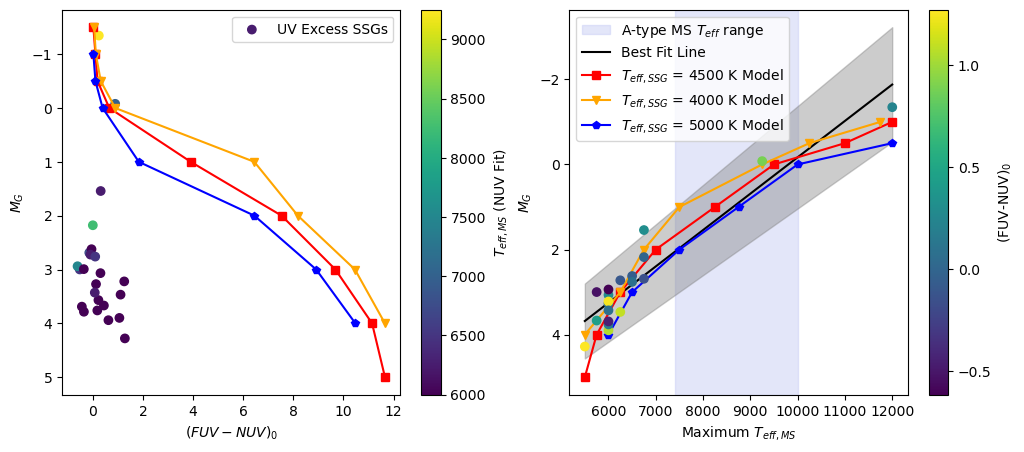

In [54]:
y_err1 = 1.54 - (t_ms_samp[t_ms_samp==6750.0]*slope + intercept)
label_ha = ['right', 'right', 'left', 'left', 'left',
           'left', 'left','left', 'left']

filt4000 = (sed_uv_dat['giant_temp'] ==4000)
filt4500 = (sed_uv_dat['giant_temp'] ==4500)
filt5000 = (sed_uv_dat['giant_temp'] ==5000)

Dra29 = (gaia_data['star'] == '29 Dra')
fig, (ax,ax2) = plt.subplots(1,2, figsize=(12,5))
cs1 = ax.scatter(sed_dat['fuv_nuv'], sed_dat['M_G'], 
                 c = sed_dat['Temperature MS (NUV Fit)'], label='UV Excess SSGs')


ax.plot(sed_uv_dat['fuv-nuv'][filt4500], sed_uv_dat['M_G'][filt4500], 
        marker='s', color = 'red')
ax.plot(sed_uv_dat['fuv-nuv'][filt4000], sed_uv_dat['M_G'][filt4000], 
        marker='v', color = 'orange')
ax.plot(sed_uv_dat['fuv-nuv'][filt5000], sed_uv_dat['M_G'][filt5000], 
        marker='p', color = 'blue')

ax.set_xlabel('$(FUV-NUV)_0$')
ax.set_ylabel('$M_G$')

cb1 = fig.colorbar(cs1, ax=ax)
cb1.set_label('$T_{eff, MS}$ (NUV Fit)')

ax.invert_yaxis()
ax.legend()


#Figure 2

ax2.axvspan(7400, 10000, color = '#C8CEF5', alpha=0.5, label='A-type MS $T_{eff}$ range')
cs = ax2.scatter(sed_dat['T_MS, Max'], sed_dat['M_G'],
                 c= sed_dat['fuv_nuv'], zorder=9)

ax2.fill_between(t_ms_samp, 
                 t_ms_samp* (slope + se) + intercept + y_err, 
                 t_ms_samp* (slope - se) + intercept - y_err, 
                     alpha=0.4, color='grey')

ax2.plot(t_ms_samp, t_ms_samp* slope + intercept, 
         ls ='-', color='black', label = 'Best Fit Line')

cb = fig.colorbar(cs, ax=ax2, ticks=[-0.5,0,0.5, 1])
cb.set_label('(FUV-NUV)$_0$')


ax2.plot(sed_uv_dat['ms_temp'][filt4500][0:-1], 
         sed_uv_dat['M_G'][filt4500][0:-1], 
         marker='s', color = 'red', label = '$T_{eff, SSG}$ = 4500 K Model')
ax2.plot(sed_uv_dat['ms_temp'][filt4000][0:-1], 
         sed_uv_dat['M_G'][filt4000][0:-1], 
         marker='v', color = 'orange', label = '$T_{eff, SSG}$ = 4000 K Model')
ax2.plot(sed_uv_dat['ms_temp'][filt5000][0:-1], 
         sed_uv_dat['M_G'][filt5000][0:-1], 
         marker='p', color = 'blue', label = '$T_{eff, SSG}$ = 5000 K Model')

ax2.set_xlabel('Maximum $T_{eff, MS}$')
ax2.set_ylabel('$M_G$')
ax2.invert_yaxis()
ax2.legend()

#for 29 Dra MS compareable at 6500

#SED sub+giant+MS M_G and Far UV (track)
# create and SED 7000 (and total find FUV-NUV) with various G-band fluxes

# 7 additonal stars from 1.5

HD 57267
ZTF J154854.35+441305.1
NV Eri
V0706 Pup


(-0.9, 6.6)

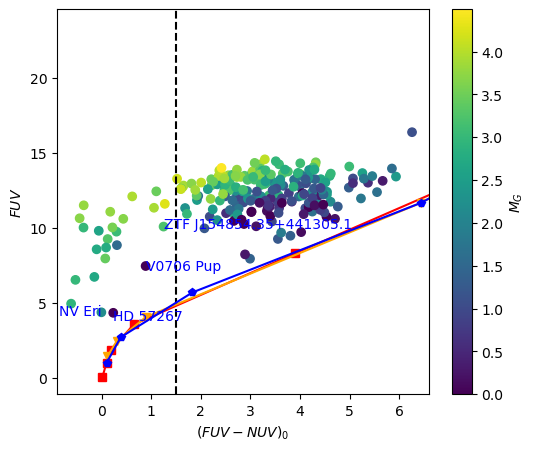

In [61]:
fig, ax = plt.subplots(1, figsize=(6,5))
cs = ax.scatter(fuv_nuv, M_fuv_ucorr, c = M_G, vmin=0)
ax.set_xlabel('$(FUV-NUV)_0$')
ax.set_ylabel('$FUV$')
ax.axvline(1.5, color='black',ls='--')
#ax.axvline(0.5, color='black',ls='--')

ax.plot(sed_uv_dat['fuv-nuv'][filt4500], 
         sed_uv_dat['fuv'][filt4500], 
         marker='s', color = 'red', label = '$T_{eff, SSG}$ = 4500 K Model')
ax.plot(sed_uv_dat['fuv-nuv'][filt4000][0:-1], 
         sed_uv_dat['fuv'][filt4000][0:-1], 
         marker='v', color = 'orange', label = '$T_{eff, SSG}$ = 4000 K Model')
ax.plot(sed_uv_dat['fuv-nuv'][filt5000][0:-1], 
         sed_uv_dat['fuv'][filt5000][0:-1], 
         marker='p', color = 'blue', label = '$T_{eff, SSG}$ = 5000 K Model')


cb = fig.colorbar(cs, ax=ax)
cb.set_label('$M_G$')

filt_for_obj = (((fuv_nuv < 1.5)  & (fuv_nuv > 0.5)  & (M_fuv_ucorr < 11)) |
               (M_fuv_ucorr < 4.6))

xorient = ['left', 'left','right','left']
for i, item in enumerate(gaia_data[filt_for_obj]):
    ax.text(fuv_nuv[filt_for_obj][i], 
            M_fuv[filt_for_obj][i], 
            item['star'], ha=xorient[i], color='blue')
    print(item['star'])
ax.set_xlim(-0.9,6.6)

In [45]:
list_1 = gaia_data[['star', 'source_id']][fuv_nuv < 1.5]
list_1

star,source_id
str28,int64
ZTF J012055.17+450752.0,397690027169628672
CSS J075410.6+141829,654503129867566080
AD LMi,755517221614519808
HD 57267,871136882231721600
CSS J081117.6+360733,906058127442277248
ZTF J141527.19+164234.7,1232279031219489792
ZTF J161259.34+250041.0,1303115931129472896
ZTF J162639.53+412116.7,1381075634865165568
ZTF J155936.55+394851.3,1382759605642657920
